In [2]:
# Libraries
library(zoo)
library(lubridate)
library(mgcv)
library(TSA)
library(dynlm)
library(ggplot2)
library(prophet)
library(tseries)
library(forecast)
library(splines)
library(vars)
library(tseries)
library(ggplot2)
library(forecast)


**Read Data**


In [206]:
rdpi = read.csv("~/Georgia Tech/ISYE-6402/Final Project/data/Real Disposable Personal Income.csv")
hrus = read.csv("~/Georgia Tech/ISYE-6402/Final Project/data/Homeownership Rate in the United States.csv")
hpi = read.csv("~/Georgia Tech/ISYE-6402/Final Project/data/S&P CoreLogic Case-Shiller U.S. National Home Price Index  - CSUSHPINSA.csv")

colnames(hrus)[2] = 'Homeownership.Rate'
colnames(hpi)[1] = 'DATE'
colnames(hpi)[2] = 'Home.Price.Index'


In [207]:
rbind(head(rdpi, 5), tail(rdpi, 5))  # Disposable Personal Income
rbind(head(hpi, 5), tail(hpi, 5))    # Home Prices

rbind(head(hrus, 5), tail(hrus, 5))  # Home Ownership Rates


,DATE,Personal.Income
,<chr>,<dbl>
1,1/1/87,6494.2
2,2/1/87,6525.0
3,3/1/87,6530.5
4,4/1/87,6282.3
5,5/1/87,6537.0
444,12/1/23,16889.2
445,1/1/24,16914.2
446,2/1/24,16897.4
447,3/1/24,16924.3


,DATE,Home.Price.Index
,<chr>,<dbl>
1,1987-01-01,63.733
2,1987-02-01,64.132
3,1987-03-01,64.468
4,1987-04-01,64.972
5,1987-05-01,65.546
451,2024-07-01,325.706
452,2024-08-01,325.148
453,2024-09-01,324.788
454,2024-10-01,324.188


,DATE,Homeownership.Rate
,<chr>,<dbl>
1,1/1/87,63.8
2,4/1/87,63.8
3,7/1/87,64.2
4,10/1/87,64.1
5,1/1/88,63.7
146,4/1/23,65.9
147,7/1/23,66.0
148,10/1/23,65.7
149,1/1/24,65.6


**Time Series Analysis**


**Personal Income**

In [144]:
ts_income = ts(rdpi$Personal.Income, start=c(1987,1), frequency=12)
ts_homeownership = ts(hrus$Homeownership.Rate, start=c(1987,1), frequency=4)
ts_hpi = ts(hpi$Home.Price.Index, start=c(1987,1), frequency=12)


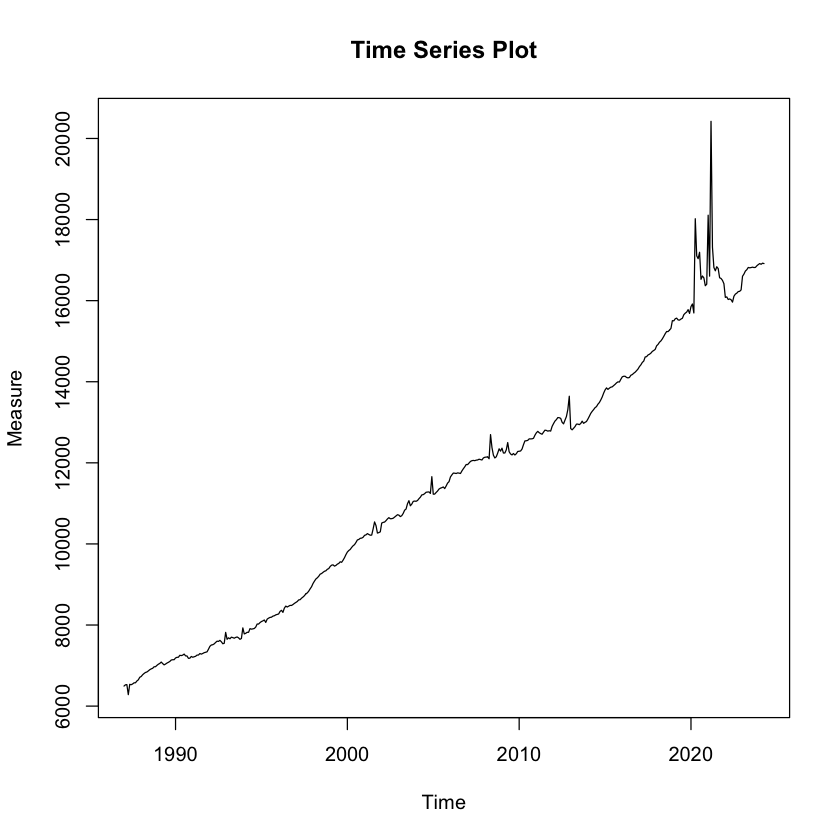

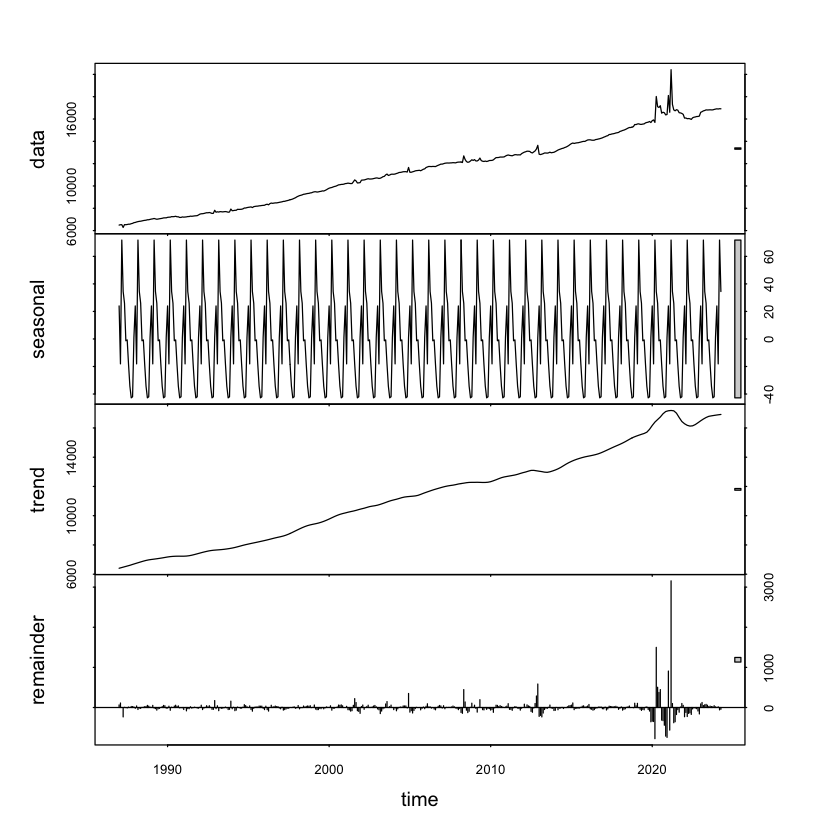

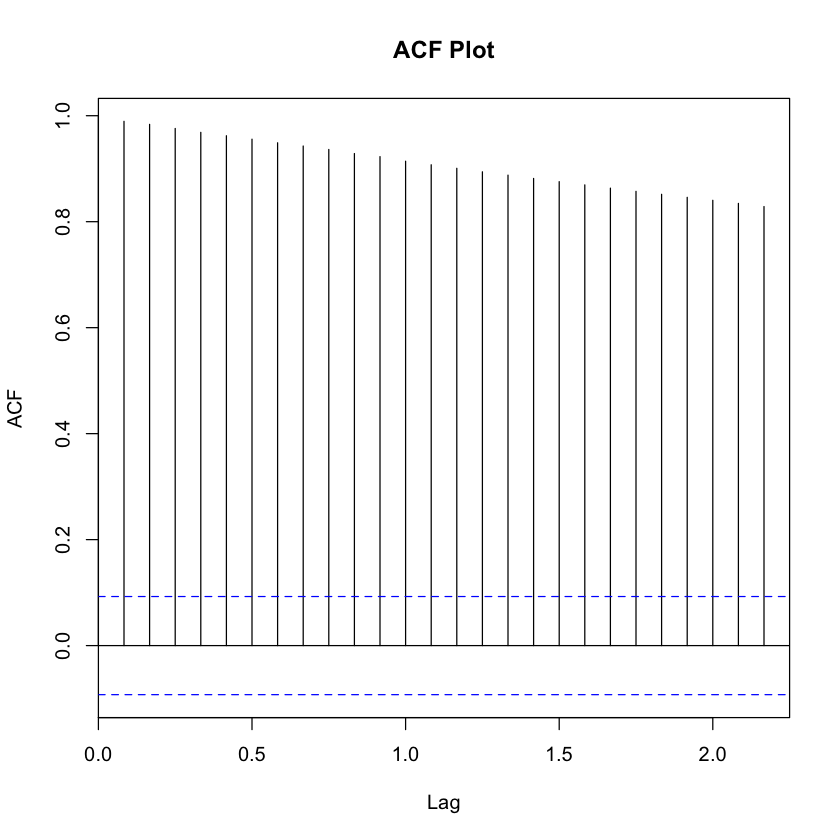

In [145]:
# Time Series & ACF Plots
plot(ts_income, main='Time Series Plot', ylab='Measure')
decomposed = stl(ts_income, s.window="periodic")
plot(decomposed)
acf(ts_income, main='ACF Plot')


In [146]:
# ADF Test: Stationarity
adf_test = adf.test(ts_income)
print(adf_test)  # Null: Non-Stationary | p-value > 0.05 >>> Non-Stationary

# KPSS Test: Stationarity
kpss_test = kpss.test(ts_income)
print(kpss_test)  # Null: Stationary | p-value < 0.05 >>> Non-Stationary

# Ljung-Box Test: Autocorrelation
ljung_test = Box.test(ts_income, type='Ljung-Box')
print(ljung_test)  # NULL: No Autocorrelation | p-value < 0.05 >>> Autocorrelation



	Augmented Dickey-Fuller Test

data:  ts_income
Dickey-Fuller = -2.6625, Lag order = 7, p-value = 0.2977
alternative hypothesis: stationary



Warning message in kpss.test(ts_income):
“p-value smaller than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_income
KPSS Level = 7.4417, Truncation lag parameter = 5, p-value = 0.01


	Box-Ljung test

data:  ts_income
X-squared = 441.49, df = 1, p-value < 2.2e-16



**Home Price index**

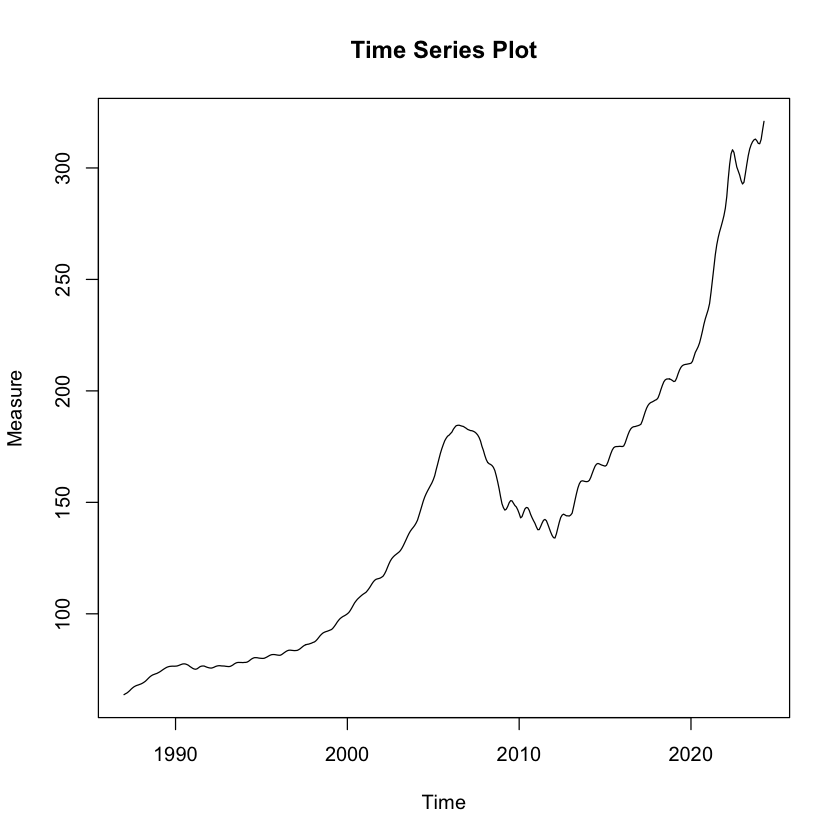

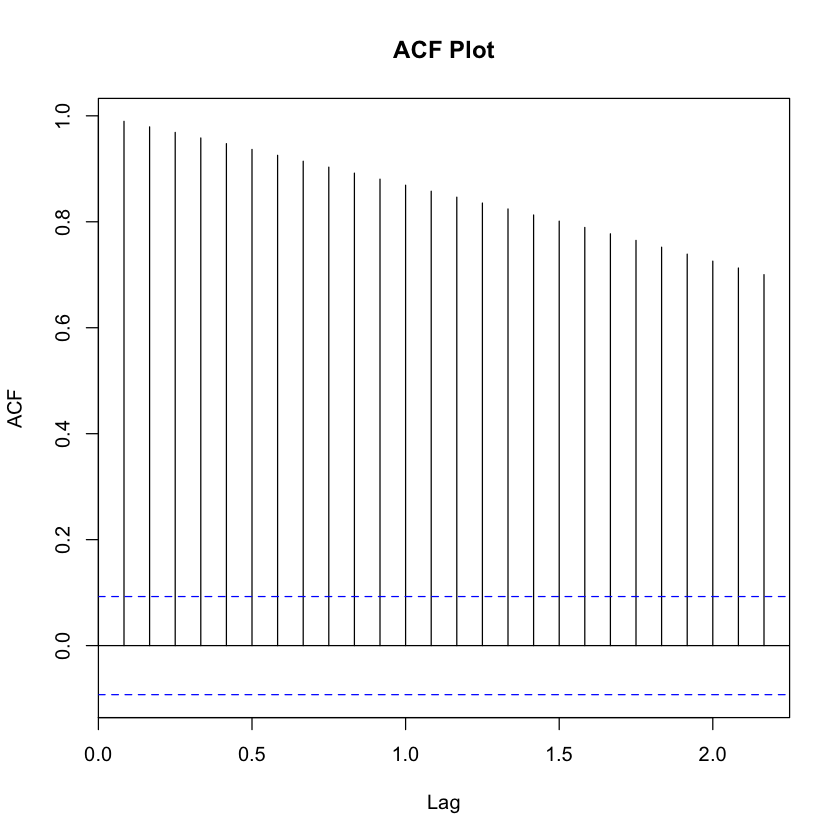

In [147]:
# Time Series & ACF Plots
plot(ts_hpi, main='Time Series Plot', ylab='Measure')
acf(ts_hpi, main='ACF Plot')

In [148]:
# ADF Test: Stationarity
adf_test = adf.test(ts_hpi)
print(adf_test)  # Null: Non-Stationary | p-value > 0.05 >>> Non-Stationary

# KPSS Test: Stationarity
kpss_test = kpss.test(ts_hpi)
print(kpss_test)  # Null: Stationary | p-value < 0.05 >>> Non-Stationary

# Ljung-Box Test: Autocorrelation
ljung_test = Box.test(ts_hpi, type='Ljung-Box')
print(ljung_test)  # NULL: No Autocorrelation | p-value < 0.05 >>> Autocorrelation


	Augmented Dickey-Fuller Test

data:  ts_hpi
Dickey-Fuller = -0.54557, Lag order = 7, p-value = 0.9797
alternative hypothesis: stationary



Warning message in kpss.test(ts_hpi):
“p-value smaller than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_hpi
KPSS Level = 6.3134, Truncation lag parameter = 5, p-value = 0.01


	Box-Ljung test

data:  ts_hpi
X-squared = 441.67, df = 1, p-value < 2.2e-16



**VARS: Differencing**


**Personal Income**

In [149]:
# Differencing: First-Order
ts_income_diff = diff(ts_income, differences=1)

# ADF Test: Stationarity
adf_test = adf.test(ts_income_diff)
print(adf_test)  # Null: Non-Stationary | p-value < 0.05 >>> Stationary

# KPSS Test: Stationarity
kpss_test = kpss.test(ts_income_diff)
print(kpss_test)  # Null: Stationary | p-value > 0.05 >>> Stationary

# Ljung-Box Test: Autocorrelation
ljung_test = Box.test(ts_income_diff, type='Ljung-Box')
print(ljung_test)  # NULL: No Autocorrelation | p-value > 0.05 >>> No Autocorrelation


Warning message in adf.test(ts_income_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts_income_diff
Dickey-Fuller = -11.362, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary



Warning message in kpss.test(ts_income_diff):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_income_diff
KPSS Level = 0.029236, Truncation lag parameter = 5, p-value = 0.1


	Box-Ljung test

data:  ts_income_diff
X-squared = 137.23, df = 1, p-value < 2.2e-16



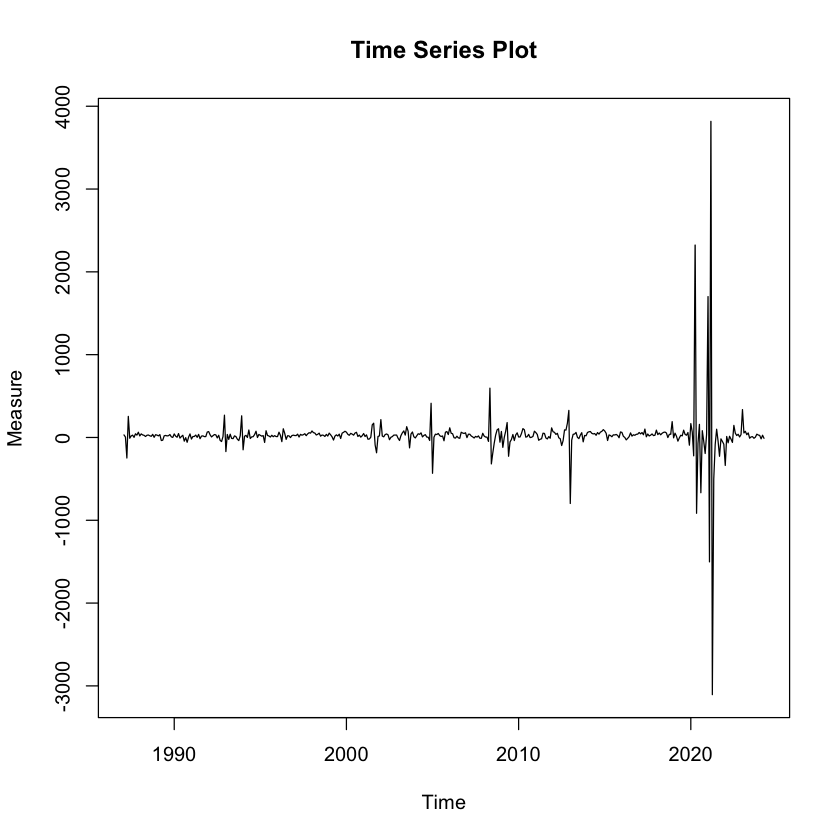

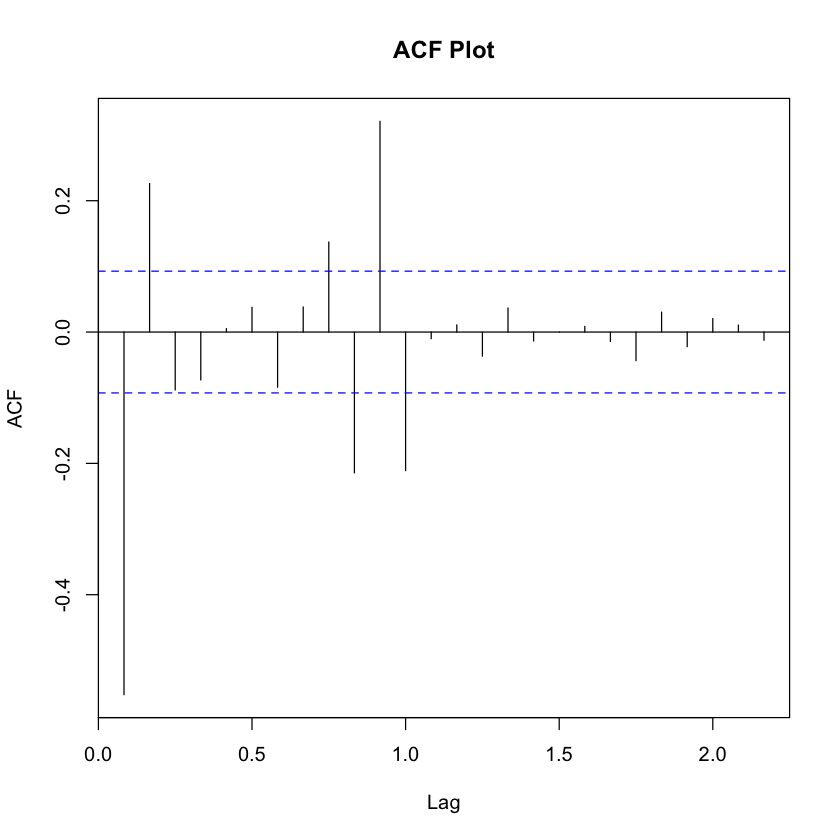

In [150]:
# Time Series & ACF Plots
plot(ts_income_diff, main='Time Series Plot', ylab='Measure')
acf(ts_income_diff, main='ACF Plot')

**Home Price Index**

In [151]:
# Differencing: Second-Order
ts_hpi_diff = diff(ts_hpi, differences=2)

# ADF Test: Stationarity
adf_test = adf.test(ts_hpi_diff)
print(adf_test)  # Null: Non-Stationary | p-value < 0.05 >>> Stationary

# KPSS Test: Stationarity
kpss_test = kpss.test(ts_hpi_diff)
print(kpss_test)  # Null: Stationary | p-value > 0.05 >>> Stationary

# Ljung-Box Test: Autocorrelation
ljung_test = Box.test(ts_hpi_diff, type='Ljung-Box')
print(ljung_test)  # NULL: No Autocorrelation | p-value > 0.05 >>> No Autocorrelation


Warning message in adf.test(ts_hpi_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts_hpi_diff
Dickey-Fuller = -15.691, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary



Warning message in kpss.test(ts_hpi_diff):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_hpi_diff
KPSS Level = 0.01855, Truncation lag parameter = 5, p-value = 0.1


	Box-Ljung test

data:  ts_hpi_diff
X-squared = 151.8, df = 1, p-value < 2.2e-16



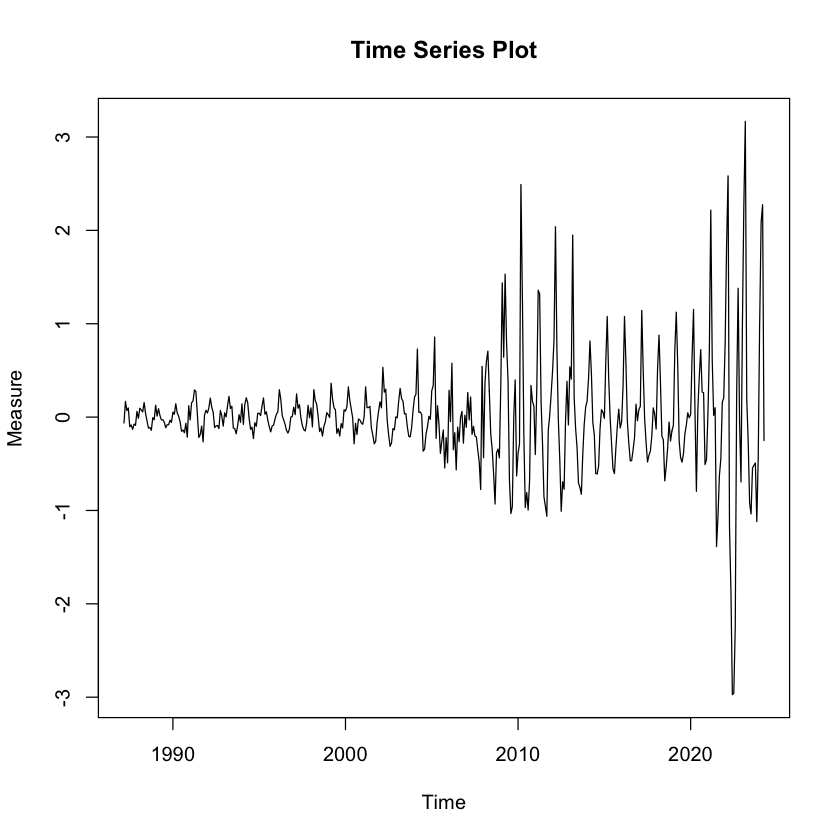

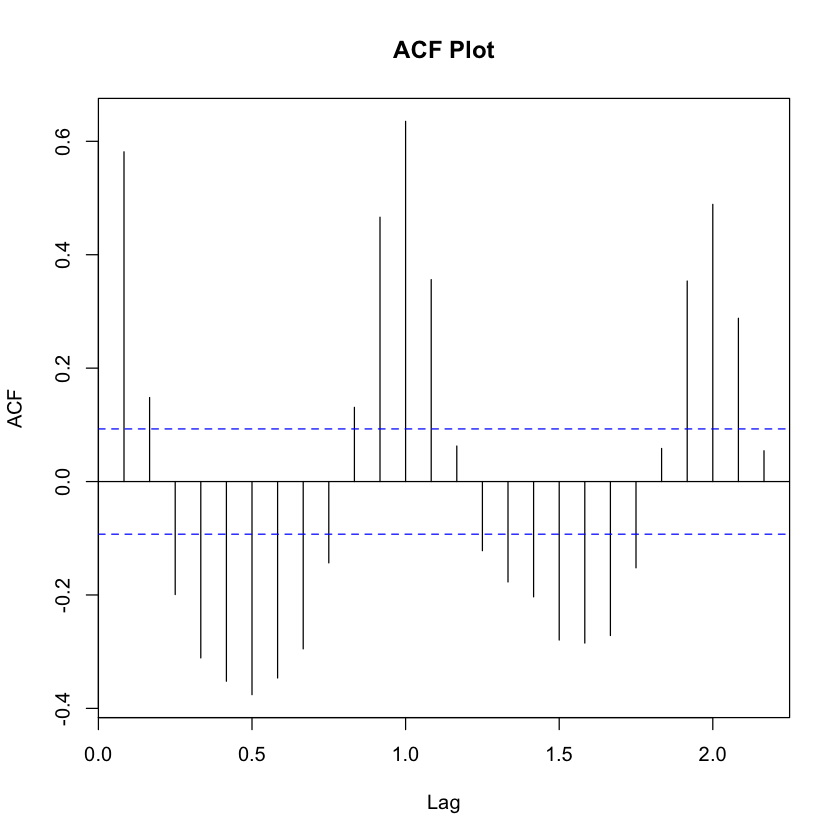

In [152]:
# Time Series & ACF Plots
plot(ts_hpi_diff, main='Time Series Plot', ylab='Measure')
acf(ts_hpi_diff, main='ACF Plot')

**Findings:**

The Vector Autoregression (VAR) model estimates the relationships between Disposable Income (ts_income) and Home Price Index (ts_hpi) over time, considering multiple lagged effects.

Home prices are primarily driven by their own past values, but disposable income does have some small but significant effects on future home prices.



In [158]:
# Create combined time series dataset
ts_data = cbind(ts_income, ts_hpi)

# Select optimal lag length using Akaike Information Criterion (AIC)
lag_selection = VARselect(ts_data, lag.max=12, type="const")
optimal_lag = lag_selection$selection["AIC(n)"]

# Fit the VAR model
var_model = VAR(ts_data, p=optimal_lag, type="const")

# Model summary
summary(var_model)



VAR Estimation Results:
Endogenous variables: ts_income, ts_hpi 
Deterministic variables: const 
Sample size: 436 
Log Likelihood: -3154.279 
Roots of the characteristic polynomial:
1.001 0.9906 0.9906 0.9735 0.9735 0.9335 0.9335 0.9208 0.9208 0.9166 0.9166 0.9029 0.9029 0.8598 0.8598 0.8369 0.8369 0.8007 0.8007 0.7764 0.7764 0.7751 0.7717 0.2694
Call:
VAR(y = ts_data, p = optimal_lag, type = "const")


Estimation results for equation ts_income: 
ts_income = ts_income.l1 + ts_hpi.l1 + ts_income.l2 + ts_hpi.l2 + ts_income.l3 + ts_hpi.l3 + ts_income.l4 + ts_hpi.l4 + ts_income.l5 + ts_hpi.l5 + ts_income.l6 + ts_hpi.l6 + ts_income.l7 + ts_hpi.l7 + ts_income.l8 + ts_hpi.l8 + ts_income.l9 + ts_hpi.l9 + ts_income.l10 + ts_hpi.l10 + ts_income.l11 + ts_hpi.l11 + ts_income.l12 + ts_hpi.l12 + const 

                Estimate Std. Error t value Pr(>|t|)    
ts_income.l1     0.36185    0.04830   7.491 4.21e-13 ***
ts_hpi.l1       15.86576   30.63536   0.518  0.60481    
ts_income.l2     0.41766   

In [157]:
# Check for serial correlation in residuals
serial.test(var_model, type="PT.asymptotic")



	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_model
Chi-squared = 210.17, df = 16, p-value < 2.2e-16

$serial

	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_model
Chi-squared = 210.17, df = 16, p-value < 2.2e-16



**Conclusion:**

Since p-value < 2.2e-16 (very small), we reject the null hypothesis, meaning there is strong evidence of autocorrelation in the residuals.

The VAR model is not capturing all dependencies in the data.
The model may need additional lags to absorb autocorrelation.
Some important external factors (exogenous variables) may be missing.
The model might be underfitting.


**Granger**

✅ Income significantly predicts home prices.</br>
✅ Home prices have a weaker but noticeable influence on income.</br>
🚫 There is no evidence of instantaneous causality.</br>


In [159]:
# Load necessary library
library(vars)

# Granger causality test: Does income Granger-cause home prices?
granger_income <- causality(var_model, cause="ts_income")
print(granger_income)

# Granger causality test: Do home prices Granger-cause income?
granger_hpi <- causality(var_model, cause="ts_hpi")
print(granger_hpi)


$Granger

	Granger causality H0: ts_income do not Granger-cause ts_hpi

data:  VAR object var_model
F-Test = 5.0013, df1 = 12, df2 = 822, p-value = 4.647e-08


$Instant

	H0: No instantaneous causality between: ts_income and ts_hpi

data:  VAR object var_model
Chi-squared = 0.0075797, df = 1, p-value = 0.9306


$Granger

	Granger causality H0: ts_hpi do not Granger-cause ts_income

data:  VAR object var_model
F-Test = 1.916, df1 = 12, df2 = 822, p-value = 0.02935


$Instant

	H0: No instantaneous causality between: ts_hpi and ts_income

data:  VAR object var_model
Chi-squared = 0.0075797, df = 1, p-value = 0.9306




In [160]:
# Portmanteau Test for autocorrelation
serial_test <- serial.test(var_model, type="PT.asymptotic")
print(serial_test)




	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_model
Chi-squared = 210.17, df = 16, p-value < 2.2e-16



$serial

	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_model
Chi-squared = 210.17, df = 16, p-value < 2.2e-16



In [161]:
# Jarque-Bera test for normality
normality_test <- normality.test(var_model)
print(normality_test)



$JB

	JB-Test (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 73484, df = 4, p-value < 2.2e-16


$Skewness

	Skewness only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 1760.2, df = 2, p-value < 2.2e-16


$Kurtosis

	Kurtosis only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 71724, df = 2, p-value < 2.2e-16




$jb.mul
$jb.mul$JB

	JB-Test (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 73484, df = 4, p-value < 2.2e-16


$jb.mul$Skewness

	Skewness only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 1760.2, df = 2, p-value < 2.2e-16


$jb.mul$Kurtosis

	Kurtosis only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 71724, df = 2, p-value < 2.2e-16




In [162]:
# White’s test for heteroscedasticity
arch_test <- arch.test(var_model)
print(arch_test)




	ARCH (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 200.34, df = 45, p-value < 2.2e-16



$arch.mul

	ARCH (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 200.34, df = 45, p-value < 2.2e-16



In [163]:
lag_selection <- VARselect(ts_data, lag.max=15, type="const")
optimal_lag <- lag_selection$selection["AIC(n)"]
var_model_new <- VAR(ts_data, p=optimal_lag, type="const")



In [164]:
ts_data_log <- log(ts_data)
var_model_log <- VAR(ts_data_log, p=optimal_lag, type="const")


In [166]:
library(rugarch)


**1. Are there specific characteristics of the time series representing disposable income that contribute most to the predictability of the time series?**



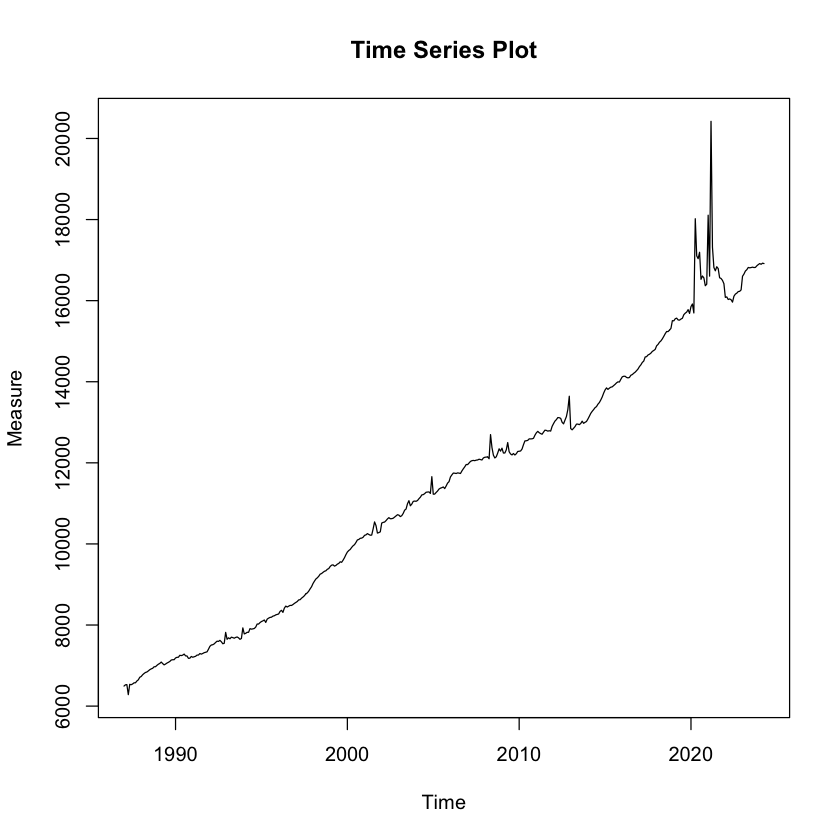

In [170]:
# Time Series & ACF Plots
plot(ts_income, main='Time Series Plot', ylab='Measure')


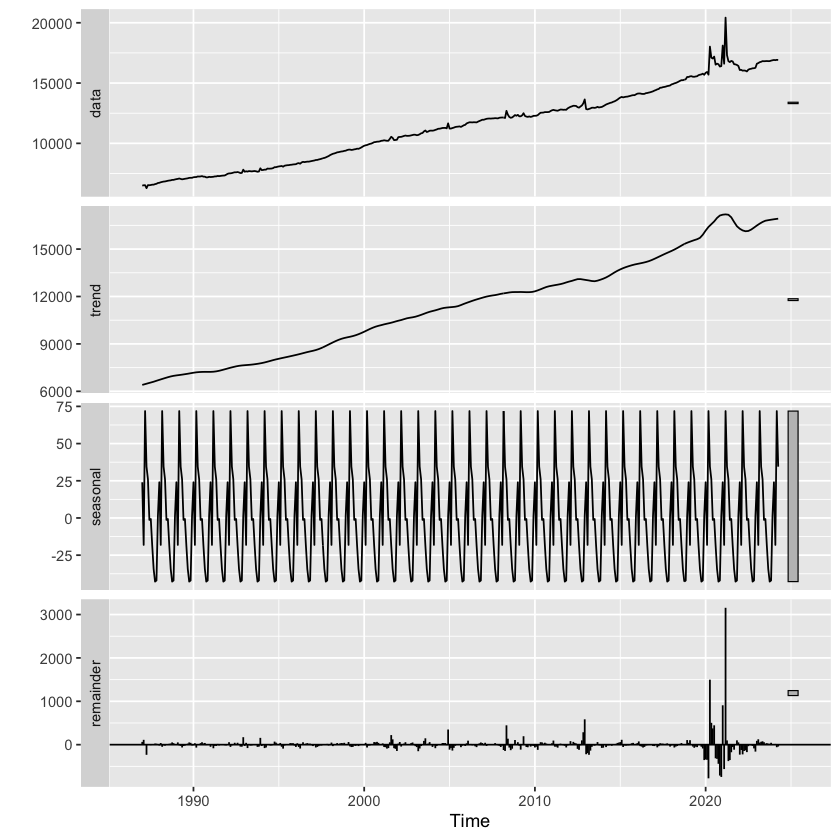

In [171]:
# Time Series Decomposed
decomposed = stl(ts_income, s.window='periodic')
autoplot(decomposed)


In [205]:
# Model 1: Trend Only
trend_only_model = lm(ts_income ~ time)
summary(trend_only_model)

# Model 2: Trend + Seasonality
seasonality = cycle(ts_income)
full_model = lm(ts_income ~ time + as.factor(seasonality))
summary(full_model)

# Performance Difference: R-Squared
round(summary(full_model)$r.squared - summary(trend_only_model)$r.squared, 6)



Call:
lm(formula = ts_income ~ time)

Residuals:
   Min     1Q Median     3Q    Max 
-778.6 -271.8  -12.1  167.0 4526.1 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 5981.3109    40.0340   149.4   <2e-16 ***
time          24.1245     0.1545   156.1   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 423 on 446 degrees of freedom
Multiple R-squared:  0.982,	Adjusted R-squared:  0.982 
F-statistic: 2.438e+04 on 1 and 446 DF,  p-value: < 2.2e-16



Call:
lm(formula = ts_income ~ time + as.factor(seasonality))

Residuals:
   Min     1Q Median     3Q    Max 
-805.4 -265.3  -16.6  167.2 4449.0 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)              6007.1082    77.4532  77.558   <2e-16 ***
time                       24.1259     0.1559 154.765   <2e-16 ***
as.factor(seasonality)2   -40.6285    97.8832  -0.415    0.678    
as.factor(seasonality)3    50.7587    97.8836   0.519    0.604    
as.factor(seasonality)4    13.8986    97.8842   0.142    0.887    
as.factor(seasonality)5     3.7460    98.5427   0.038    0.970    
as.factor(seasonality)6   -24.6448    98.5423  -0.250    0.803    
as.factor(seasonality)7   -25.1112    98.5422  -0.255    0.799    
as.factor(seasonality)8   -45.6885    98.5423  -0.464    0.643    
as.factor(seasonality)9   -64.3414    98.5427  -0.653    0.514    
as.factor(seasonality)10  -74.9187    98.5433  -0.760    0.448    
as.factor(seasonality)11  -76.2473

[1] 0.000136

[1] 448

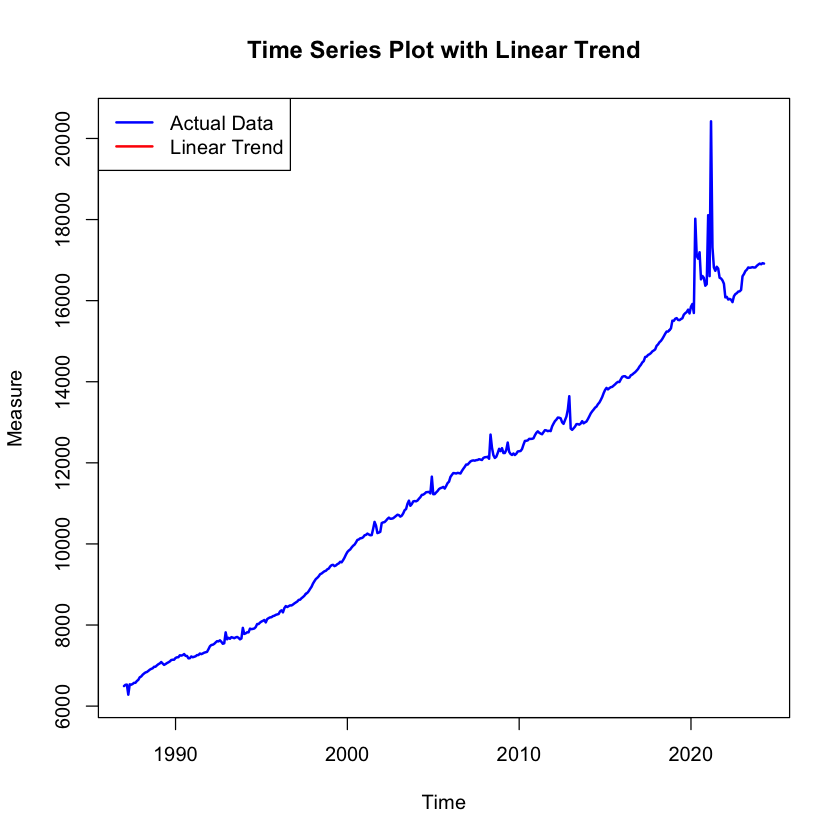

In [204]:
# Linear Trend Model
time_index = 1:length(ts_income)
trend_model = lm(ts_income ~ time_index)
trend_line = predict(trend_model)
length(trend_line)

# Time Series Plot
plot(ts_income, main="Time Series Plot with Linear Trend", ylab="Measure", col="blue", lwd=2)
lines(trend_line, col="red", lwd=2)
legend("topleft", legend=c("Actual Data", "Linear Trend"), col=c("blue", "red"), lwd=2)


In [ ]:
2.	Is there any relationship between the personal income and the home price index? 
VAR + Granger
